In [19]:
import pandas as pd
from analyses.data_readers.recording_metadata_reader import RecordingMetadataReader
# read zombies anova passed cells -- this is used for the grant
# all_anova_passed_cells_old.xlsx is the same as zombies_all_anova_passed_cells--used for grant.xlsx
zombies_sig_windows = pd.read_excel('all_anova_passed_cells_old.xlsx')

# Now clean and reformat the DataFrame to match the format used in the current data pipeline
reader = RecordingMetadataReader()
prelim = reader.get_metadata_for_preliminary_analysis()
prelim['Location'] = prelim['Location'].replace({'Amygdala': 'AMG'})
prelim['Location'] = prelim['Location'].fillna('Unknown')
zombies_sig_windows = zombies_sig_windows.merge(
    prelim[['Date', 'Round No.', 'Location']],
    on=['Date', 'Round No.'],
    how='left'
)

# generate NeuronID column
zombies_sig_windows['NeuronID'] = (
        zombies_sig_windows['Location'].astype(str) + "_" +
        zombies_sig_windows['Date'].astype(str) + "_" +
        zombies_sig_windows['Round No.'].astype(str) + "_" +
        zombies_sig_windows['Cell'].astype(str))
# generate WindowStart and WindowEnd columns
zombies_sig_windows['Time Window'] = zombies_sig_windows['Time Window'].apply(
    lambda s: tuple(int(float(num)) for num in s.strip('()').split(',')))
zombies_sig_windows[['WindowStart_ms', 'WindowEnd_ms']] = zombies_sig_windows['Time Window'].apply(pd.Series)
zombies_sig_windows.drop(zombies_sig_windows.columns[[0, 1]], axis=1, inplace=True)
zombies_sig_windows

,Date,Round No.,Time Window,Cell,P Value,Location,NeuronID,WindowStart_ms,WindowEnd_ms
0,2023-09-26,1,"(0, 300)",Channel.C_027_Unit 1,0.030966,AMG,AMG_2023-09-26_1_Channel.C_027_Unit 1,0,300
1,2023-09-26,2,"(700, 1000)",Channel.C_011_Unit 1,0.022412,AMG,AMG_2023-09-26_2_Channel.C_011_Unit 1,700,1000
2,2023-09-26,2,"(50, 150)",Channel.C_020,0.004885,AMG,AMG_2023-09-26_2_Channel.C_020,50,150
3,2023-09-26,3,"(0, 2000)",Channel.C_002_Unit 1,0.000105,AMG,AMG_2023-09-26_3_Channel.C_002_Unit 1,0,2000
4,2023-09-26,3,"(100, 200)",Channel.C_007_Unit 2,0.031938,AMG,AMG_2023-09-26_3_Channel.C_007_Unit 2,100,200
...,...,...,...,...,...,...,...,...,...
70,2023-12-14,4,"(1900, 2000)",Channel.C_006,0.014833,ER,ER_2023-12-14_4_Channel.C_006,1900,2000
71,2023-12-14,4,"(750, 850)",Channel.C_008,0.042302,ER,ER_2023-12-14_4_Channel.C_008,750,850
72,2023-12-18,2,"(200, 350)",Channel.C_012_Unit 2,0.037932,ER,ER_2023-12-18_2_Channel.C_012_Unit 2,200,350
73,2023-12-18,3,"(2000, 2150)",Channel.C_015_Unit 1,0.037427,ER,ER_2023-12-18_3_Channel.C_015_Unit 1,2000,2150


In [33]:
windows = pd.read_pickle('/old/old_analysis_cache/Zombies_response_windows.pkl')
windows

,NeuronID,WindowStart_ms,WindowEnd_ms
0,AMG_2023-09-26_1_Channel.C_014_Unit 1,150,500
1,AMG_2023-09-26_1_Channel.C_018_Unit 1,50,150
2,AMG_2023-09-26_1_Channel.C_018_Unit 1,1750,1850
3,AMG_2023-09-26_1_Channel.C_018_Unit 2,100,200
4,AMG_2023-09-26_1_Channel.C_018_Unit 2,350,450
...,...,...,...
586,Unknown_2023-12-18_3_Channel.C_015_Unit 1,1300,1400
587,Unknown_2023-12-18_3_Channel.C_015_Unit 1,2000,2150
589,Unknown_2023-12-18_3_Channel.C_021_Unit 1,1000,1300
588,Unknown_2023-12-18_3_Channel.C_021_Unit 1,600,800


In [32]:
neurons = pd.read_pickle('/old/old_analysis_cache/Zombies_significant_neurons_pANOVAorGLM_passed.pkl')
neurons[neurons['Permutation_pval_corrected']<0.05]


,NeuronID,GLM_p-value,F-statistic,PermANOVA_p-value,GLM_pval_corrected,GLM_significant,Permutation_pval_corrected,Permutation_significant
35,AMG_2023-10-03_3_Channel.C_006,1.289495e-41,4.908539,0.000,2.321092e-41,True,0.0000,True
45,AMG_2023-10-03_4_Channel.C_010,2.075773e-55,2.950508,0.004,9.340977e-55,True,0.0360,True
52,AMG_2023-10-04_1_Channel.C_004_Unit 1,2.534711e-51,5.618690,0.000,4.055538e-51,True,0.0000,True
56,AMG_2023-10-04_1_Channel.C_019_Unit 3,8.775909e-40,3.634309,0.001,8.775909e-40,True,0.0040,True
64,AMG_2023-10-04_2_Channel.C_018_Unit 1,6.459850e-55,4.591991,0.001,2.288768e-54,True,0.0045,True
66,AMG_2023-10-04_2_Channel.C_020_Unit 2,9.207931e-54,6.757271,0.000,1.657428e-53,True,0.0000,True
69,AMG_2023-10-04_3_Channel.C_002_Unit 1,3.602361e-49,3.483538,0.004,5.043305e-49,True,0.0280,True
128,AMG_2023-10-11_1_Channel.C_002,1.621880e-50,4.368647,0.001,2.703134e-50,True,0.0050,True
142,AMG_2023-10-11_3_Channel.C_013,1.303510e-29,3.432098,0.002,1.955265e-29,True,0.0120,True
258,ER_2023-11-28_4_Channel.C_015,2.907249e-07,2.636300,0.008,5.233048e-07,True,0.0270,True


In [23]:
from analyses.single_neuron_analysis import merge_glm_and_permutation_anova
from analyses.spike_count import extract_spike_counts_from_windows

from analyses.response_window_analysis import run_permutation_anova_by_window, run_glm_by_window

test = zombies_sig_windows[['NeuronID', 'WindowStart_ms', 'WindowEnd_ms']] 
spike_counts_windows = extract_spike_counts_from_windows(test)
group_specific_spike_counts_for_windows = spike_counts_windows[spike_counts_windows['MonkeyGroup'] == 'Zombies']
panova_results, _ = run_permutation_anova_by_window(group_specific_spike_counts_for_windows,
                                category_col='MonkeyName',
                                neuron_col='NeuronID',
                                count_col='SpikeCount',
                                window_start_col='WindowStart_ms',
                                window_end_col='WindowEnd_ms',
                                n_permutations=1000,
                                alpha=0.05,
                                plot=False)
glm_results, _ = run_glm_by_window(group_specific_spike_counts_for_windows, formula="SpikeCount ~ C(MonkeyName)")
all_results = merge_glm_and_permutation_anova(glm_results, panova_results)
significant_windows = all_results[(all_results["GLM_significant"]) | (all_results["Permutation_significant"])]

Running Perm ANOVA per (Neuron, Window): 100%|██████████| 60/60 [00:10<00:00,  5.49it/s]



All Results:
                                 NeuronID  WindowStart_ms  WindowEnd_ms  \
0   AMG_2023-09-26_1_Channel.C_027_Unit 1               0           300   
1          AMG_2023-09-26_2_Channel.C_020              50           150   
2   AMG_2023-09-26_3_Channel.C_007_Unit 2             100           200   
3   AMG_2023-09-26_3_Channel.C_027_Unit 2             150           350   
4          AMG_2023-10-03_4_Channel.C_006             450           650   
5          AMG_2023-10-03_4_Channel.C_026            1000          1100   
6   AMG_2023-10-04_1_Channel.C_004_Unit 1             100           700   
7   AMG_2023-10-04_1_Channel.C_004_Unit 1             150           400   
8   AMG_2023-10-04_1_Channel.C_019_Unit 3             100           500   
9   AMG_2023-10-04_1_Channel.C_019_Unit 3             150           400   
10  AMG_2023-10-04_2_Channel.C_018_Unit 1             100           500   
11  AMG_2023-10-04_2_Channel.C_018_Unit 1             150           500   
12  AMG_202

Running GLM per (Neuron, Window): 100%|██████████| 60/60 [00:00<00:00, 203.47it/s]


GLM Significant windows:
                     index     Coef.  Std.Err.          z         P>|z|  \
0                Intercept  2.133509  0.114708  18.599499  3.243259e-77   
2    C(MonkeyName)[T.151J] -0.379490  0.179968  -2.108645  3.497526e-02   
5    C(MonkeyName)[T.7124]  0.308838  0.147829   2.089153  3.669399e-02   
27               Intercept  2.172223  0.112509  19.307143  4.677418e-83   
30    C(MonkeyName)[T.67G] -0.344096  0.174686  -1.969793  4.886214e-02   
..                     ...       ...       ...        ...           ...   
538   C(MonkeyName)[T.69X] -1.767662  0.408959  -4.322347  1.543781e-05   
539  C(MonkeyName)[T.7124] -1.228665  0.328213  -3.743505  1.814710e-04   
540   C(MonkeyName)[T.72X] -1.228665  0.328213  -3.743505  1.814710e-04   
541   C(MonkeyName)[T.87J] -0.622530  0.264281  -2.355555  1.849505e-02   
542   C(MonkeyName)[T.94B] -1.005522  0.301756  -3.332232  8.615235e-04   

       [0.025    0.975]                               NeuronID  \
0    1.

In [29]:
l = significant_windows[significant_windows['PermANOVA_p-value'] < 0.05]
l[['NeuronID', 'WindowStart_ms', 'WindowEnd_ms', 'PermANOVA_p-value']]

,NeuronID,WindowStart_ms,WindowEnd_ms,PermANOVA_p-value
0,AMG_2023-09-26_1_Channel.C_027_Unit 1,0,300,0.034
1,AMG_2023-09-26_2_Channel.C_020,50,150,0.005
2,AMG_2023-09-26_3_Channel.C_007_Unit 2,100,200,0.045
3,AMG_2023-09-26_3_Channel.C_027_Unit 2,150,350,0.045
4,AMG_2023-10-03_4_Channel.C_006,450,650,0.003
5,AMG_2023-10-03_4_Channel.C_026,1000,1100,0.037
6,AMG_2023-10-04_1_Channel.C_004_Unit 1,100,700,0.000
7,AMG_2023-10-04_1_Channel.C_004_Unit 1,150,400,0.000
8,AMG_2023-10-04_1_Channel.C_019_Unit 3,100,500,0.000
9,AMG_2023-10-04_1_Channel.C_019_Unit 3,150,400,0.000


In [3]:
from analyses.linear_regression.behavior_vector_linear_regression import \
    run_directional_vector_linear_regression_window_level
from analyses.spike_rate import compute_mean_spike_rate_for_windows
import os
from analyses.enums.monkey_names import get_monkeys_by_default_order

monkey_group = "Zombies"
subject_monkey_index = 6
monkey_list = get_monkeys_by_default_order(monkey_group)
base_dir = '/home/connorlab/Documents/GitHub/Julie//social_data/zombies_social_data/'
behavior_files = {
    "AffiliationTo": "zombies_feature_df_affiliation.xlsx",
    "AffiliationFrom": "zombies_feature_df_affiliation.xlsx",
    "SubmissionTo": "zombies_feature_df_submission.xlsx",
    "SubmissionFrom": "zombies_feature_df_submission.xlsx",
    "AgonismTo": "zombies_feature_df_agonism.xlsx",
    "AgonismFrom": "zombies_feature_df_agonism.xlsx",
}

behavior_matrices = {
    name: pd.read_excel(os.path.join(base_dir, fname)).iloc[:, 1:].to_numpy().T if 'From' in name
    else pd.read_excel(os.path.join(base_dir, fname)).iloc[:, 1:].to_numpy()
    for name, fname in behavior_files.items()
}

In [4]:
# Directional Linear Regression (OLS) on Significant Windows
mean_spike_rate_windows = compute_mean_spike_rate_for_windows(zombies_sig_windows)
all_window_results = []
for name, mat in behavior_matrices.items():
    results_df = run_directional_vector_linear_regression_window_level(
        mean_spike_rate_windows, mat, name, monkey_group, monkey_list, subject_monkey_index, use_spikerate=True
    )
    all_window_results.append(results_df)
all_window_results_df = pd.concat(all_window_results, ignore_index=True)
all_window_results_df

Computing windowed mean spike rate: 100%|██████████| 75/75 [00:01<00:00, 58.90it/s]
Computing window-level linear regression with directional vectors: 100%|██████████| 60/60 [00:00<00:00, 180.30it/s]
Computing window-level linear regression with directional vectors: 100%|██████████| 60/60 [00:00<00:00, 192.55it/s]
Computing window-level linear regression with directional vectors: 100%|██████████| 60/60 [00:00<00:00, 191.77it/s]
Computing window-level linear regression with directional vectors: 100%|██████████| 60/60 [00:00<00:00, 195.23it/s]
Computing window-level linear regression with directional vectors: 100%|██████████| 60/60 [00:00<00:00, 211.60it/s]
Computing window-level linear regression with directional vectors: 100%|██████████| 60/60 [00:00<00:00, 209.84it/s]


,NeuronID,WindowStart_ms,WindowEnd_ms,Behavior,Source_Monkey,Model,R-squared,coef,intercept,p_value,p_perm
0,AMG_2023-09-26_1_Channel.C_027_Unit 1,0.0,300.0,AffiliationTo,7124,ols,0.297116,-0.097158,2.706346,0.162365,None
1,AMG_2023-09-26_1_Channel.C_027_Unit 1,0.0,300.0,AffiliationTo,69X,ols,0.159603,-0.060525,1.763004,0.326817,None
2,AMG_2023-09-26_1_Channel.C_027_Unit 1,0.0,300.0,AffiliationTo,72X,ols,0.167999,-0.062581,1.834475,0.313217,None
3,AMG_2023-09-26_1_Channel.C_027_Unit 1,0.0,300.0,AffiliationTo,94B,ols,0.081236,-0.049410,1.380747,0.493824,None
4,AMG_2023-09-26_1_Channel.C_027_Unit 1,0.0,300.0,AffiliationTo,110E,ols,0.014496,-0.018241,0.531316,0.776426,None
...,...,...,...,...,...,...,...,...,...,...,...
3235,ER_2023-12-14_4_Channel.C_008,750.0,850.0,AgonismFrom,110E,ols,0.020619,-0.030115,0.350091,0.734444,None
3236,ER_2023-12-14_4_Channel.C_008,750.0,850.0,AgonismFrom,67G,ols,0.156385,0.037081,-0.579391,0.332198,None
3237,ER_2023-12-14_4_Channel.C_008,750.0,850.0,AgonismFrom,143H,ols,0.132676,0.033929,-0.525905,0.375041,None
3238,ER_2023-12-14_4_Channel.C_008,750.0,850.0,AgonismFrom,87J,ols,0.000112,-0.001003,0.014038,0.980149,None


In [6]:
all_window_results_sorted = all_window_results_df.sort_values(by=['p_value','R-squared'], ascending=False)
filtered_df = all_window_results_df[(all_window_results_df['R-squared'] > 0.6)]
# mean_spike_rate = compute_mean_spike_rate_for_windows(filtered_df)

In [7]:
spike_count = pd.read_excel('/home/connorlab/Documents/GitHub/Julie/Cortana/Ed and ANOVA/used_for_R01/zombies_spike_counts_for_all_anova_passed_time_windowed_cells_old--usedforgrant.xlsx')
spike_count = spike_count.merge(
    prelim[['Date', 'Round No.', 'Location']],
    on=['Date', 'Round No.'],
    how='left'
)

# generate NeuronID column
spike_count['NeuronID'] = (
        spike_count['Location'].astype(str) + "_" +
        spike_count['Date'].astype(str) + "_" +
        spike_count['Round No.'].astype(str) + "_" +
        spike_count['Cell'].astype(str))
# generate WindowStart and WindowEnd columns
spike_count['Time Window'] = spike_count['Time Window'].apply(
    lambda s: tuple(int(float(num)) for num in s.strip('()').split(',')))
spike_count[['WindowStart_ms', 'WindowEnd_ms']] =spike_count['Time Window'].apply(pd.Series)
always_keep = ['NeuronID','WindowStart_ms', 'WindowEnd_ms', 'Cell']
columns_to_keep = always_keep + [col for col in spike_count.columns if col in monkey_list]
spike_count_filtered = spike_count[columns_to_keep]
spike_count_filtered

,NeuronID,WindowStart_ms,WindowEnd_ms,Cell,69X,67G,72X,94B,7124,151J,110E,87J,143H
0,AMG_2023-09-26_1_Channel.C_027_Unit 1,0,300,Channel.C_027_Unit 1,"[0, 6, 8, 11, 8, 14, 9, 11, 9]","[3, 4, 6, 3, 9, 5, 10, 9, 13, 9]","[12, 8, 5, 7, 11, 7, 7, 14, 3, 6]","[4, 7, 17, 9, 18, 11, 13]","[6, 6, 23, 10, 12, 14, 10, 13, 12, 9]","[3, 5, 6, 7, 7, 10, 6, 2, 6]","[8, 5, 6, 6, 16, 7, 6, 6, 16]","[8, 14, 6, 9, 11, 9, 4, 16, 14, 14]","[2, 1, 11, 4, 5, 12, 8, 11, 10, 9]"
1,AMG_2023-09-26_2_Channel.C_011_Unit 1,700,1000,Channel.C_011_Unit 1,"[0, 3, 1, 3, 1, 0, 1, 1, 1]","[0, 0, 0, 0, 0, 0, 0, 0, 1, 1]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 1]","[0, 0, 2, 0, 0, 0, 1, 0, 0]","[0, 2, 0, 3, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 1, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 1, 0, 0, 1, 0, 0, 0]","[0, 0, 4, 0, 1, 0, 2, 0, 0, 0]"
2,AMG_2023-09-26_2_Channel.C_020,50,150,Channel.C_020,"[2, 1, 1, 1, 0, 1, 0, 1, 2]","[2, 1, 2, 1, 1, 1, 1, 0, 1, 1]","[1, 1, 1, 1, 0, 1, 0, 1, 1, 1]","[1, 2, 0, 0, 0, 1, 0, 0, 0]","[1, 1, 1, 0, 0, 1, 0, 1, 0]","[2, 1, 1, 0, 0, 1, 1, 1, 1]","[1, 1, 1, 2, 1, 1, 1, 0, 0, 1]","[1, 0, 0, 0, 1, 0, 1, 0, 1, 0]","[2, 2, 1, 1, 1, 2, 1, 2, 0, 3]"
3,AMG_2023-09-26_3_Channel.C_002_Unit 1,0,2000,Channel.C_002_Unit 1,"[0, 2, 0, 1, 0, 3, 0, 0, 0, 3]","[0, 0, 0, 1, 1, 0, 0, 0, 1]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[1, 0, 0, 1, 0, 0, 0, 0, 2, 0]","[0, 6, 0, 2, 1, 1, 4, 1, 3, 0]","[2, 7, 0, 0, 1, 0, 1, 0]","[1, 2, 1, 0, 0, 4, 1, 5, 0]","[5, 8, 4, 1, 0, 10, 7, 3, 1]","[4, 1, 3, 2, 0, 0, 0, 0, 0, 0]"
4,AMG_2023-09-26_3_Channel.C_007_Unit 2,100,200,Channel.C_007_Unit 2,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[1, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 1, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0]","[1, 1, 0, 0, 1, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,ER_2023-12-14_4_Channel.C_006,1900,2000,Channel.C_006,"[0, 0, 0, 4, 1, 2, 0, 0, 0, 5]","[4, 1, 0, 4, 0, 0, 1, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[1, 3, 2, 0, 0, 0, 0, 4, 3, 1]","[3, 0, 0, 0, 0, 1, 1, 0, 1, 3]","[0, 0, 0, 0, 0, 0, 0, 0, 1, 0]","[0, 0, 3, 0, 0, 7, 5, 2, 0, 2]","[0, 0, 2, 0, 0, 0, 1, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
71,ER_2023-12-14_4_Channel.C_008,750,850,Channel.C_008,"[2, 0, 1, 1, 2, 0, 0, 1, 0, 0]","[1, 3, 0, 0, 0, 1, 1, 2, 1, 0]","[1, 1, 2, 0, 2, 1, 1, 4, 0, 0]","[0, 1, 1, 1, 0, 1, 8, 2, 0, 1]","[0, 1, 0, 1, 1, 1, 0, 1, 2, 5]","[1, 0, 0, 0, 1, 1, 1, 1, 1, 0]","[0, 4, 4, 7, 1, 1, 0, 18, 2, 4]","[2, 0, 0, 1, 3, 2, 1, 3, 10, 0]","[1, 1, 0, 3, 1, 1, 0, 3, 0, 0]"
72,ER_2023-12-18_2_Channel.C_012_Unit 2,200,350,Channel.C_012_Unit 2,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 2, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 3, 0, 2, 0, 0, 1, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
73,ER_2023-12-18_3_Channel.C_015_Unit 1,2000,2150,Channel.C_015_Unit 1,"[0, 0, 1, 1, 0, 1, 0, 2, 1, 2]","[0, 0, 1, 0, 1, 0, 1, 1, 1, 3]","[0, 2, 2, 4, 0, 2, 2, 3, 2, 1]","[0, 0, 1, 2, 0, 1, 1, 0, 1, 2]","[0, 0, 0, 1, 1, 0, 2, 1, 2, 1]","[0, 0, 0, 0, 0, 2, 0, 1, 1, 0]","[1, 1, 0, 1, 1, 0, 0, 0, 1, 0]","[1, 0, 2, 0, 1, 1, 0, 2, 1, 2]","[0, 0, 0, 0, 0, 1, 0, 3, 2, 0]"


In [8]:
import pandas as pd
import ast

# Helper: convert from string to list if needed
def to_list(val):
    if isinstance(val, str):
        try:
            evaluated = ast.literal_eval(val)
            if isinstance(evaluated, list):
                return evaluated
        except:
            return None
    return val if isinstance(val, list) else None

# Helper: compute average if it's a list of numbers
def average_list(val):
    if isinstance(val, list) and all(isinstance(x, (int, float)) for x in val) and len(val) > 0:
        return sum(val) / len(val)
    return None

# Step 1: Identify list-containing columns
list_cols = [
    col for col in spike_count_filtered.columns
    if spike_count_filtered[col].dropna().apply(to_list).apply(lambda x: isinstance(x, list)).any()
]

# Step 2: Create a new DataFrame with averaged values only in those columns
df_avg = spike_count_filtered.copy()
for col in list_cols:
    df_avg[col] = spike_count_filtered[col].apply(lambda x: average_list(to_list(x)))

df_avg

,NeuronID,WindowStart_ms,WindowEnd_ms,Cell,69X,67G,72X,94B,7124,151J,110E,87J,143H
0,AMG_2023-09-26_1_Channel.C_027_Unit 1,0,300,Channel.C_027_Unit 1,8.444444,7.100000,8.0,11.285714,11.500000,5.777778,8.444444,10.500000,7.3
1,AMG_2023-09-26_2_Channel.C_011_Unit 1,700,1000,Channel.C_011_Unit 1,1.222222,0.200000,0.1,0.333333,0.555556,0.111111,0.000000,0.200000,0.7
2,AMG_2023-09-26_2_Channel.C_020,50,150,Channel.C_020,1.000000,1.100000,0.8,0.444444,0.555556,0.888889,0.900000,0.400000,1.5
3,AMG_2023-09-26_3_Channel.C_002_Unit 1,0,2000,Channel.C_002_Unit 1,0.900000,0.333333,0.0,0.400000,1.800000,1.375000,1.555556,4.333333,1.0
4,AMG_2023-09-26_3_Channel.C_007_Unit 2,100,200,Channel.C_007_Unit 2,0.000000,0.111111,0.0,0.000000,0.100000,0.000000,0.000000,0.333333,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,ER_2023-12-14_4_Channel.C_006,1900,2000,Channel.C_006,1.200000,1.000000,0.0,1.400000,0.900000,0.100000,1.900000,0.300000,0.0
71,ER_2023-12-14_4_Channel.C_008,750,850,Channel.C_008,0.700000,0.900000,1.2,1.500000,1.200000,0.600000,4.100000,2.200000,1.0
72,ER_2023-12-18_2_Channel.C_012_Unit 2,200,350,Channel.C_012_Unit 2,0.000000,0.200000,0.1,0.600000,0.000000,0.000000,0.000000,0.000000,0.0
73,ER_2023-12-18_3_Channel.C_015_Unit 1,2000,2150,Channel.C_015_Unit 1,0.800000,0.800000,1.8,0.800000,0.800000,0.400000,0.500000,1.000000,0.6


In [9]:
# New Directional Linear Regression (OLS) function
from tqdm import tqdm
import statsmodels.api as sm
from scipy.stats import zscore
import numpy as np
import pandas as pd
from scipy.stats import zscore
import statsmodels.api as sm
from tqdm import tqdm

# Inputs: assume you have these defined
# spike_df = ...
# behavior_matrix = ...
# monkey_list = ...
# subject_monkey_index = ...
# behavior_name = "AffiliationTo"  # or whatever you're analyzing
# model_type = 'ols'
# permutation_test = False
# n_perm = 10000
behavior_name = "AffiliationTo"
behavior_matrix = behavior_matrices[behavior_name]
results = []
spike_df = df_avg
# Identify monkey columns in spike_df
monkey_columns = [col for col in spike_df.columns if col in monkey_list]

printed_lines = []
# Loop over each row (one neuron × window)
for i, row in spike_df.iterrows():
    neuron_id = row['NeuronID']
    win_start = row['WindowStart_ms']
    win_end = row['WindowEnd_ms']
    
    for src_idx, src_monkey in enumerate(monkey_list):
        # if src_monkey not in monkey_columns:
        #     # print(f"Skipping {src_monkey} (not in spike_df)")
        #     continue
        # if src_idx == subject_monkey_index:
        #     # print(f"Skipping subject monkey {src_monkey}")
        #     continue
    
        subject_monkey = monkey_list[subject_monkey_index]

        try:
            # Get behavior vector (source → others)
            raw_y = behavior_matrix[src_idx].copy()
            valid_mask = np.array([
                (m != src_monkey) and (m in monkey_columns)
                # and (m != subject_monkey) 
                for m in monkey_list
            ])
            y = zscore(raw_y[valid_mask])

            # Get neural values (mean spike count from each monkey)
            x = row[[m for m, keep in zip(monkey_list, valid_mask) if keep]].values.astype(float)
            # Skip low variance or length mismatch
            if np.var(x) < 1e-3 or np.var(y) < 1e-3:
                continue
            if len(x) != len(y):
                continue

            # Run regression
            X = sm.add_constant(x)
            model = sm.OLS(y, X).fit()
            r_squared = model.rsquared
            if r_squared > 0.5:
                line = f"BEH 0 cell {i} source monkey {src_monkey} Rsquared = {r_squared:.12f}"
                print(line)
                printed_lines.append(line)

            results.append({
                'NeuronID': neuron_id,
                'WindowStart_ms': win_start,
                'WindowEnd_ms': win_end,
                'Behavior': behavior_name,
                'Source_Monkey': src_monkey,
                'R-squared': r_squared,
                'coef': model.params[1],
                'intercept': model.params[0],
                'p_value': model.pvalues[1],
            })
        except Exception as e:
            print(f"Error at row {i}, source {src_monkey}: {e}")
            continue
with open("affiliation_from_results.txt", "w") as f:
    for line in printed_lines:
        f.write(line + "\n")
# Final results DataFrame
results_df = pd.DataFrame(results)
# print(results_df)


BEH 0 cell 0 source monkey 94B Rsquared = 0.509273464788
BEH 0 cell 1 source monkey 69X Rsquared = 0.645153609708
BEH 0 cell 1 source monkey 94B Rsquared = 0.524912968397
BEH 0 cell 1 source monkey 143H Rsquared = 0.799192924481
BEH 0 cell 3 source monkey 81G Rsquared = 0.601092095187
BEH 0 cell 6 source monkey 110E Rsquared = 0.684303909437
BEH 0 cell 7 source monkey 110E Rsquared = 0.737073186144
BEH 0 cell 8 source monkey 67G Rsquared = 0.767944024316
BEH 0 cell 11 source monkey 67G Rsquared = 0.508597460396
BEH 0 cell 13 source monkey 7124 Rsquared = 0.578417136145
BEH 0 cell 13 source monkey 151J Rsquared = 0.871955089027
BEH 0 cell 23 source monkey 7124 Rsquared = 0.640086279814
BEH 0 cell 24 source monkey 7124 Rsquared = 0.687353247338
BEH 0 cell 26 source monkey 72X Rsquared = 0.513920162673
BEH 0 cell 26 source monkey 67G Rsquared = 0.501179105136
BEH 0 cell 27 source monkey 7124 Rsquared = 0.620918284615
BEH 0 cell 27 source monkey 151J Rsquared = 0.837524571206
BEH 0 cell 28

In [10]:
results_df

,NeuronID,WindowStart_ms,WindowEnd_ms,Behavior,Source_Monkey,R-squared,coef,intercept,p_value
0,AMG_2023-09-26_1_Channel.C_027_Unit 1,0,300,AffiliationTo,7124,0.026820,0.097302,-0.813112,0.698381
1,AMG_2023-09-26_1_Channel.C_027_Unit 1,0,300,AffiliationTo,69X,0.010299,0.051251,-0.447855,0.811017
2,AMG_2023-09-26_1_Channel.C_027_Unit 1,0,300,AffiliationTo,72X,0.136374,0.187947,-1.652815,0.367961
3,AMG_2023-09-26_1_Channel.C_027_Unit 1,0,300,AffiliationTo,94B,0.509273,0.412380,-3.457116,0.046822
4,AMG_2023-09-26_1_Channel.C_027_Unit 1,0,300,AffiliationTo,110E,0.139519,0.188631,-1.648348,0.362062
...,...,...,...,...,...,...,...,...,...
745,ER_2023-12-18_3_Channel.C_020_Unit 1,150,400,AffiliationTo,67G,0.165464,-0.788560,0.384423,0.317257
746,ER_2023-12-18_3_Channel.C_020_Unit 1,150,400,AffiliationTo,81G,0.045391,0.434890,-0.202949,0.582058
747,ER_2023-12-18_3_Channel.C_020_Unit 1,150,400,AffiliationTo,143H,0.021555,0.300076,-0.157540,0.728652
748,ER_2023-12-18_3_Channel.C_020_Unit 1,150,400,AffiliationTo,87J,0.698400,1.667763,-0.854728,0.009766


In [12]:
valid = pd.read_pickle('/old/old_analysis_cache/Zombies_significant_windows_pANOVAorGLM_passed.pkl')
valid

,NeuronID,GLM_p-value,WindowStart_ms,WindowEnd_ms,F-statistic,PermANOVA_p-value,GLM_pval_corrected,GLM_significant,Permutation_pval_corrected,Permutation_significant
0,AMG_2023-09-26_1_Channel.C_014_Unit 1,0.000000,150,500,1.640527,0.124,0.000000,True,0.796795,False
1,AMG_2023-09-26_1_Channel.C_018_Unit 1,0.028004,50,150,0.875831,0.544,0.035139,True,0.903101,False
2,AMG_2023-09-26_1_Channel.C_018_Unit 1,0.028004,1750,1850,0.850747,0.586,0.035139,True,0.904142,False
3,AMG_2023-09-26_1_Channel.C_018_Unit 2,0.010077,100,200,0.867503,0.569,0.015714,True,0.904142,False
4,AMG_2023-09-26_1_Channel.C_018_Unit 2,0.010077,350,450,1.542621,0.151,0.015714,True,0.796795,False
...,...,...,...,...,...,...,...,...,...,...
586,Unknown_2023-12-18_3_Channel.C_015_Unit 1,0.011281,1300,1400,1.030063,0.420,0.017499,True,0.896032,False
587,Unknown_2023-12-18_3_Channel.C_015_Unit 1,0.011281,2000,2150,2.180261,0.025,0.017499,True,0.492500,False
588,Unknown_2023-12-18_3_Channel.C_021_Unit 1,0.010047,600,800,1.065941,0.392,0.015714,True,0.896032,False
589,Unknown_2023-12-18_3_Channel.C_021_Unit 1,0.010047,1000,1300,1.104037,0.360,0.015714,True,0.882822,False


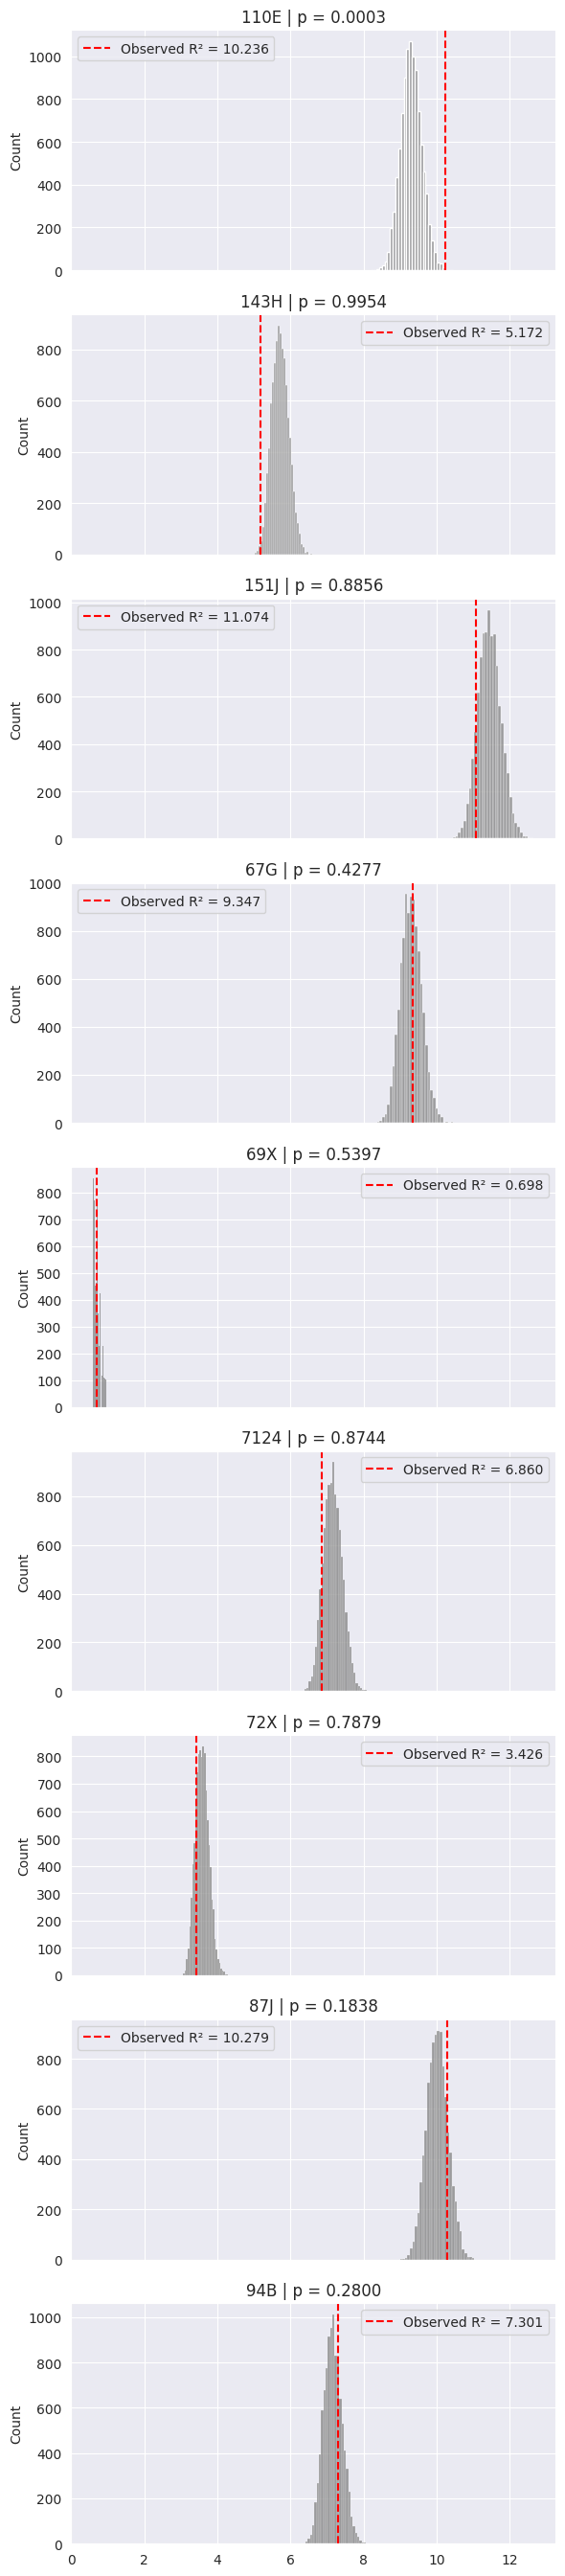

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
# Settings
n_permutations = 10000
source_col = 'Source_Monkey'
r2_col = 'R-squared'
filtered_results = filtered_df
# Step 1: Observed R² sums
observed = filtered_results.groupby(source_col)[r2_col].sum()

# Step 2: Permutations
perm_sums = {monkey: [] for monkey in observed.index}

for _ in range(n_permutations):
    shuffled = filtered_df.copy()
    shuffled[source_col] = np.random.permutation(shuffled[source_col].values)
    permuted_sum = shuffled.groupby(source_col)[r2_col].sum()

    for monkey in observed.index:
        perm_sums[monkey].append(permuted_sum.get(monkey, 0))

# Step 3: Compute p-values
p_values = {}
for monkey in observed.index:
    perm_array = np.array(perm_sums[monkey])
    obs = observed[monkey]
    p = np.mean(perm_array >= obs)
    p_values[monkey] = p

# Step 4: Plot
fig, axs = plt.subplots(len(observed), 1, figsize=(6, 3 * len(observed)), sharex=True)

for i, monkey in enumerate(observed.index):
    ax = axs[i]
    sns.histplot(perm_sums[monkey], bins=30, kde=False, ax=ax, color='gray')
    ax.axvline(observed[monkey], color='red', linestyle='--', label=f"Observed R² = {observed[monkey]:.3f}")
    ax.set_title(f"{monkey} | p = {p_values[monkey]:.4f}")
    ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
results = pd.read_pickle('saved_r2_permutation_results.pkl')

In [25]:
import matplotlib.pyplot as plt
import numpy as np

monkeys = ['7124', '69X', '72X', '94B', '110E', '67G', '81G', '143H', '87J', '151J']
sum_r2 = results['sumRsquared']
nless = results['nless']
n_perm = 10000

# p-value 계산
p_values = [(n_perm - n) / n_perm for n in nless]
neg_log_p = [-np.log10(p + 1e-6) for p in p_values]

# plot
plt.figure(figsize=(9, 5))
bars = plt.bar(monkeys, neg_log_p, color='mediumpurple')
plt.axhline(-np.log10(0.05), color='red', linestyle='--', label='p = 0.05')

# 별표 annotate
def get_star(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return ''

for i, (bar, p) in enumerate(zip(bars, p_values)):
    star = get_star(p)
    if star:
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, star,
                 ha='center', va='bottom', fontsize=14, fontweight='bold')

plt.ylabel('-log10(p-value)')
plt.ylim(0,3)
plt.title('Significance of Neural Variance Explained by Each Monkey')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()



NameError: name 'results' is not defined

In [ ]:
monkeys = ['7124', '69X', '72X', '94B', '110E', '67G', '81G', '143H', '87J', '151J']
plt.bar(monkeys, results['sumRsquared'])
plt.ylabel('Total R² Explained')
plt.title('Total Neural Variance Explained by Source Monkey')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
behaviors = ['AffTo', 'AffFrom', 'SubTo', 'SubFrom', 'AgnTo', 'AgnFrom']
plt.bar(behaviors, results['behsumRsquared'])
plt.ylabel('Total R² Explained')
plt.title('Variance Explained by Behavior')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
sns.heatmap(np.array(results['behmnksumRsquared']),
            xticklabels=monkeys,
            yticklabels=behaviors,
            annot=True, fmt=".1f", cmap='Blues')
plt.title('R² Sum per Source Monkey × Behavior')
plt.xlabel('Source Monkey')
plt.ylabel('Behavior')
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

n_perm = 10000
behaviors = ['AffTo', 'AffFrom', 'SubTo', 'SubFrom', 'AgnTo', 'AgnFrom']
p_values = [(n_perm - n) / n_perm for n in results['nlessbehavior']]
neg_log_p = [-np.log10(p + 1e-6) for p in p_values]  # for plotting

# 별표 지정 함수
def get_star(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return ''

# Plot
plt.figure(figsize=(8, 5))
bars = plt.bar(behaviors, neg_log_p, color='salmon')
plt.axhline(-np.log10(0.05), color='red', linestyle='--', label='p = 0.05')

# 별표 annotate
for i, (bar, p) in enumerate(zip(bars, p_values)):
    star = get_star(p)
    if star:
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, star,
                 ha='center', va='bottom', fontsize=14, fontweight='bold')

plt.ylabel('-log10(p-value)')
plt.title('Significance of Neural Variance Explained for Social Behaviors')
plt.legend()
plt.tight_layout()
plt.show()

